# Joining Land Registry Price Data with Energy Performance Certificates (2015 - 2025)

#### Load Price data

In [182]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.expand_frame_repr', False)


folder = Path('../data/raw')
file_gen = folder.glob('ppd_data*.csv')
pp_raw = pd.concat([pd.read_csv(f) for f in file_gen], ignore_index=True)
pp_raw['deed_date'] = pp_raw['deed_date'].astype('datetime64[ns]')

#### Load EPC data

In [183]:
epc_raw = pd.read_csv('../data/raw/EDC_OXFORDSHIRE_2015_2025.csv', usecols= [
    'certificate_number', 'address1', 'address2', 'address3', 'postcode',
    'posttown', 'address', 'local_authority', 'local_authority_label',
    'built_form', 'construction_age_band', 'current_energy_efficiency',
    'current_energy_rating', 'energy_consumption_current', 'extension_count', 'floor_height', 'heating_cost_current',
    'inspection_date', 'lodgement_date', 'number_habitable_rooms',
    'number_heated_rooms', 'potential_energy_efficiency', 'property_type',
    'tenure', 'total_floor_area', 'transaction_type', 'uprn', 'uprn_source'
])
epc_raw['inspection_date'] = epc_raw['inspection_date'].astype('datetime64[ns]')
epc_raw['lodgement_date'] = epc_raw['lodgement_date'].astype('datetime64[ns]')

#### Cleaning

Fix trailing whitespace

In [184]:
pp = pp_raw.copy()

for c in pp.select_dtypes(include=['string']).columns:
    pp[c] = pp[c].str.strip()
    print(f"{c} stripped")

unique_id stripped
postcode stripped
property_type stripped
new_build stripped
estate_type stripped
saon stripped
paon stripped
street stripped
locality stripped
town stripped
district stripped
county stripped
transaction_category stripped
linked_data_uri stripped


In [185]:
epc = epc_raw.copy()

for c in epc.select_dtypes(include=['string']).columns:
    epc[c] = epc[c].str.strip()
    print(f"{c} stripped")

certificate_number stripped
address1 stripped
address2 stripped
address3 stripped
postcode stripped
posttown stripped
address stripped
local_authority stripped
local_authority_label stripped
built_form stripped
construction_age_band stripped
current_energy_rating stripped
property_type stripped
tenure stripped
transaction_type stripped
uprn_source stripped


Remove commas

In [186]:
epc_address_cols = ['address1', 'address2', 'address3', 'postcode']
pp_address_cols = ['paon', 'saon', 'street', 'locality', 'postcode']

print(f"Commas replaced in epc:\n{epc[epc_address_cols].apply(lambda col: col.str.count(',')).sum()}")
print(f"Commas replaced in pp:\n{pp[pp_address_cols].apply(lambda col: col.str.count(',')).sum()}")

for c in epc_address_cols:
    epc[c] = epc[c].str.replace(',', '', regex=False)
for c in pp_address_cols:
    pp[c] = pp[c].str.replace(',', '', regex=False)

Commas replaced in epc:
address1    83515.0
address2     3910.0
address3      137.0
postcode        0.0
dtype: float64
Commas replaced in pp:
paon        4356.0
saon          33.0
street         0.0
locality       0.0
postcode       0.0
dtype: float64


Generate address token sets

In [187]:
pp['address'] = pp['paon'].str.cat([pp['saon'], pp['street'], pp['locality'], pp['postcode']], sep=' ', na_rep='')
print(pp['address'])
epc['address'] = epc['address1'].str.cat([epc['address2'], epc['address3'], epc['postcode']], sep=' ', na_rep='').apply(str.upper)
print(epc['address'])

0          CHILLING PLACE FARM PARK COTTAGE  BRILL HP18 9UH
1                        OAKCROFT FARM   BOARSTALL HP18 9UY
2                            TUTHER CORNER   BRILL HP18 9UZ
3                            TUTHER CORNER   BRILL HP18 9UZ
4         PIDDINGTON GATE FARM HEADLEY HOUSE  BRILL HP18...
                                ...                        
135552                   THE BUTCHERS GROUND   NORTH LEIGH 
135553                  TURLEY FARM LOTS 2 3 AND 4  HAILEY 
135554                        TURLEY LANE PLOT 154  HAILEY 
135555                       PLOTS 79-84   LONG HANBOROUGH 
135556                                114 GARAGE NEW ROAD  
Name: address, Length: 135557, dtype: str
0                                  10 NEWMAN ROAD   OX4 3UJ
1                        10 BARLOW CLOSE WHEATLEY  OX33 1NL
2                                65 CAMPBELL ROAD   OX4 3PG
3         12 ST. MICHAELS CLOSE SHIPTON-UNDER-WYCHWOOD  ...
4            FLAT 10 CANALSIDE HOUSE TRAMWAY ROAD  OX16 5B

In [188]:
pp['address_tokens'] = pp['address'].str.split().apply(frozenset)
epc['address_tokens'] = epc['address'].str.split().apply(frozenset)
print(epc['address_tokens'])

0                   frozenset({OX4, 10, ROAD, 3UJ, NEWMAN})
1         frozenset({1NL, 10, CLOSE, OX33, WHEATLEY, BAR...
2                 frozenset({OX4, ROAD, CAMPBELL, 65, 3PG})
3         frozenset({SHIPTON-UNDER-WYCHWOOD, ST., 12, CL...
4         frozenset({10, FLAT, ROAD, CANALSIDE, HOUSE, 5...
                                ...                        
216049                frozenset({APPLETONS, 7GG, OX12, 30})
216050        frozenset({6ED, WELL, 1D, ROAD, OX2, WALTON})
216051             frozenset({SYCAMORE, ROAD, 8, 9EJ, OX2})
216052         frozenset({OX4, CRESCENT, 4SW, 68, SPENCER})
216053    frozenset({OCHRE, CLOSE, 1FQ, 21, OX33, WHEATL...
Name: address_tokens, Length: 216054, dtype: object


#### Third Join (subset matching)

In [189]:
postcode_match = pp.merge(epc, on='postcode', how='inner')

def compare(row):
    return row['address_tokens_x'].issubset(row['address_tokens_y'])

postcode_match['result'] = postcode_match.apply(compare, axis=1)

In [190]:
epc['uprn'] = epc['uprn'].astype('Int64')

In [191]:
subset_matches = postcode_match[postcode_match['result']]

print(f"Third join (subset method) gives: {subset_matches['unique_id'].nunique()} matches. A matching rate of {100 * subset_matches['unique_id'].nunique()/pp.shape[0]:.1f}%")

Third join (subset method) gives: 105419 matches. A matching rate of 77.8%


Finding records where duplicate words were lost from the address in token setting

In [192]:
multi_match = subset_matches.groupby('unique_id')['uprn'].nunique()
multi_uprn = multi_match[multi_match > 1]

pp['token_count'] = pp['address'].str.count(r"\S+")
lost_tokens = pp[pp['token_count'] > pp['address_tokens'].apply(len)]
result = lost_tokens[lost_tokens['unique_id'].isin(multi_uprn.index)]

Date filtering

In [193]:
third_join = subset_matches[~subset_matches['unique_id'].isin(multi_uprn.index)]
third_join['time_to_sale'] = third_join['deed_date'] - third_join['inspection_date']

drop_neg = third_join[third_join['time_to_sale'] >= '0 days']
third_join_presale_epc = drop_neg.sort_values(by='time_to_sale', ascending=True).drop_duplicates(subset='unique_id')
print(f"Properties remaining with matched pre-sale EPCs: {third_join_presale_epc.shape[0]}")
print(f"Corresponds to a {100 * third_join_presale_epc.shape[0]/pp.shape[0]:.1f}% match rate")

Properties remaining with matched pre-sale EPCs: 91150
Corresponds to a 67.2% match rate


Drop matching and helping columns

In [194]:
cols_to_keep = ['unique_id', 'price_paid', 'deed_date', 'address_x', 'saon', 'paon', 'street', 'locality', 'town', 'district',  
                'postcode', 'property_type_x', 'new_build', 'estate_type',  'transaction_category',  'certificate_number', 
                'built_form', 'construction_age_band', 'current_energy_efficiency', 'current_energy_rating', 
                'energy_consumption_current', 'extension_count', 'floor_height', 'heating_cost_current', 
                'inspection_date', 'lodgement_date', 'number_habitable_rooms', 'number_heated_rooms', 
                'potential_energy_efficiency', 'property_type_y', 'tenure', 'total_floor_area', 
                'transaction_type', 'uprn', 'uprn_source', 'time_to_sale']

df = third_join_presale_epc[cols_to_keep]
df = df.rename(columns={'property_type_x':'property_subtype', 'property_type_y':'property_type', 'time_to_sale':'inspection_to_sale'})

df.dtypes

unique_id                                  str
price_paid                               int64
deed_date                       datetime64[ns]
address_x                                  str
saon                                       str
paon                                       str
street                                     str
locality                                   str
town                                       str
district                                   str
postcode                                   str
property_subtype                           str
new_build                                  str
estate_type                                str
transaction_category                       str
certificate_number                         str
built_form                                 str
construction_age_band                      str
current_energy_efficiency                int64
current_energy_rating                      str
energy_consumption_current               int64
extension_cou

Check date dtypes and ranges

In [195]:
dates = ['inspection_date', 'lodgement_date', 'deed_date']

print(df[dates].dtypes)

print(df[dates].agg(['min', 'max']).T)

inspection_date    datetime64[ns]
lodgement_date     datetime64[ns]
deed_date          datetime64[ns]
dtype: object
                       min        max
inspection_date 2013-10-31 2025-12-11
lodgement_date  2015-01-02 2025-12-13
deed_date       2015-01-07 2025-12-23


Create EPC age bands from 'inspection_to_sale'

In [196]:
df['inspection_to_sale'] = df['inspection_to_sale'].dt.days

bins = [0, 365, 1095, 1825, 3650, np.inf]
labels = ['0-1 years', '1-3 years', '3-5 years', '5-10 years', '10 years+']

df['EPC_age_band'] = pd.cut(df['inspection_to_sale'], bins=bins, labels=labels, include_lowest=True)
df['EPC_age_band'].value_counts().sort_index()

EPC_age_band
0-1 years     61097
1-3 years     14484
3-5 years      7388
5-10 years     8090
10 years+        91
Name: count, dtype: int64

Add flag for expired EPCs (10 years from lodgement_date)

In [197]:
df['EPC_expired'] = ((df['deed_date'] > (df['lodgement_date'] + pd.DateOffset(years=10))))
print(pd.concat([df['EPC_expired'].value_counts(),
df['EPC_expired'].value_counts(normalize=True)], axis=1))

             count  proportion
EPC_expired                   
False        91088     0.99932
True            62     0.00068


Monthly/Quarterly sales on full dataset

In [198]:
print(f" Using full raw price paid set shape: {pp_raw.shape}")
pp_raw_prices = pp_raw[['deed_date', 'price_paid']].set_index('deed_date')
quarterly_medians = pp_raw_prices.resample('QE').agg(['count', 'median']).reset_index()
monthly_medians = pp_raw_prices.resample('ME').agg(['count', 'median']).reset_index()

monthly_medians.columns = ['deed_date', 'count', 'median']
monthly_medians['month'] = monthly_medians['deed_date'].dt.month
monthly_medians['quarter'] = monthly_medians['deed_date'].dt.quarter
monthly_medians['year'] = monthly_medians['deed_date'].dt.year
print(monthly_medians)

 Using full raw price paid set shape: (135557, 16)
     deed_date  count    median  month  quarter  year
0   2015-01-31    687  285000.0      1        1  2015
1   2015-02-28    686  278500.0      2        1  2015
2   2015-03-31    934  275622.5      3        1  2015
3   2015-04-30    830  280000.0      4        2  2015
4   2015-05-31    955  284995.0      5        2  2015
..         ...    ...       ...    ...      ...   ...
127 2025-08-31   1066  410000.0      8        3  2025
128 2025-09-30    962  420000.0      9        3  2025
129 2025-10-31    994  391750.0     10        4  2025
130 2025-11-30    823  410000.0     11        4  2025
131 2025-12-31    756  390000.0     12        4  2025

[132 rows x 6 columns]


In [199]:
print(f" Using matched set shape: {df.shape}")
df_prices = df[['deed_date', 'price_paid']].set_index('deed_date')
match_monthly_medians = df_prices.resample('ME').agg(['count', 'median']).reset_index()

match_monthly_medians.columns = ['deed_date', 'count', 'median']
match_monthly_medians['month'] = match_monthly_medians['deed_date'].dt.month
match_monthly_medians['quarter'] = match_monthly_medians['deed_date'].dt.quarter
match_monthly_medians['year'] = match_monthly_medians['deed_date'].dt.year
print(match_monthly_medians)

 Using matched set shape: (91150, 38)
     deed_date  count    median  month  quarter  year
0   2015-01-31     24  306472.5      1        1  2015
1   2015-02-28     38  282500.0      2        1  2015
2   2015-03-31    152  262500.0      3        1  2015
3   2015-04-30    148  275000.0      4        2  2015
4   2015-05-31    299  290000.0      5        2  2015
..         ...    ...       ...    ...      ...   ...
127 2025-08-31    943  400000.0      8        3  2025
128 2025-09-30    849  415000.0      9        3  2025
129 2025-10-31    863  390000.0     10        4  2025
130 2025-11-30    721  400000.0     11        4  2025
131 2025-12-31    675  385000.0     12        4  2025

[132 rows x 6 columns]


     deed_date  month  quarter  year  full_set_count  full_set_median  matched_set_count  matched_set_median
0   2015-01-31      1        1  2015             687         285000.0                 24            306472.5
1   2015-02-28      2        1  2015             686         278500.0                 38            282500.0
2   2015-03-31      3        1  2015             934         275622.5                152            262500.0
3   2015-04-30      4        2  2015             830         280000.0                148            275000.0
4   2015-05-31      5        2  2015             955         284995.0                299            290000.0
..         ...    ...      ...   ...             ...              ...                ...                 ...
127 2025-08-31      8        3  2025            1066         410000.0                943            400000.0
128 2025-09-30      9        3  2025             962         420000.0                849            415000.0
129 2025-10-31     

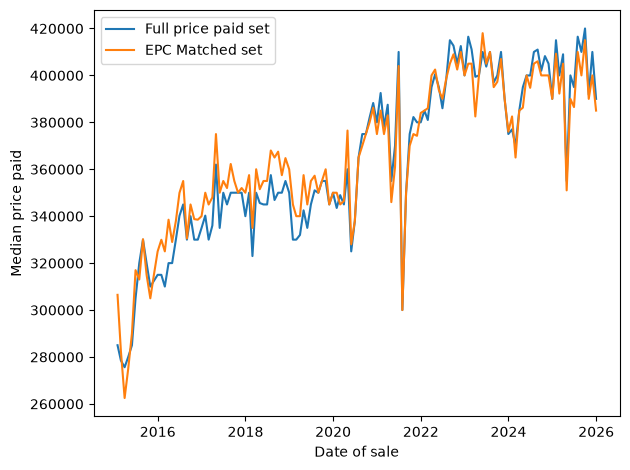

In [200]:
comparison_table = pd.concat([monthly_medians, match_monthly_medians], axis=1, keys=['Full_set', 'Matched_set'])

comparison_table = pd.DataFrame({
    'deed_date': comparison_table[('Full_set', 'deed_date')],
    'month': comparison_table[('Full_set', 'month')],
    'quarter': comparison_table[('Full_set', 'quarter')],
    'year': comparison_table[('Full_set', 'year')],
    'full_set_count': comparison_table[('Full_set', 'count')],
    'full_set_median': comparison_table[('Full_set', 'median')],
    'matched_set_count': comparison_table[('Matched_set', 'count')],
    'matched_set_median': comparison_table[('Matched_set', 'median')],
})

print(comparison_table)
fig, ax = plt.subplots()
sns.lineplot(comparison_table, x= 'deed_date', y='full_set_median', ax=ax, label='Full price paid set')
sns.lineplot(comparison_table, x= 'deed_date', y='matched_set_median', ax=ax, label='EPC Matched set')
ax.legend()
ax.set_ylabel('Median price paid')
ax.set_xlabel('Date of sale')
plt.tight_layout()
plt.show()

Checking match rate over time

<Axes: xlabel='deed_date', ylabel='match_rate'>

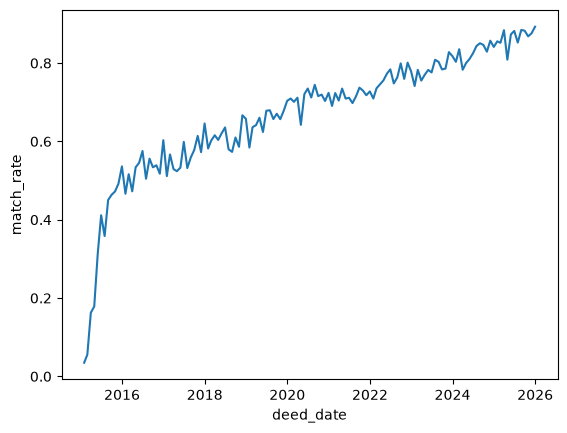

In [201]:
comparison_table['match_rate'] = comparison_table['matched_set_count'] / comparison_table['full_set_count']

sns.lineplot(comparison_table, x='deed_date', y='match_rate')

Adding datetime calendar features to joined/matched data

In [202]:
df['dayofweek'] = df['deed_date'].dt.dayofweek
df['day'] = df['deed_date'].dt.day
df['month'] = df['deed_date'].dt.month
df['quarter'] = df['deed_date'].dt.quarter
df['year'] = df['deed_date'].dt.year

print(df.sample())

                                    unique_id  price_paid  deed_date                                address_x saon paon           street     locality     town             district  postcode property_subtype new_build estate_type transaction_category        certificate_number built_form construction_age_band  current_energy_efficiency current_energy_rating  energy_consumption_current  extension_count  floor_height  heating_cost_current inspection_date lodgement_date  number_habitable_rooms  number_heated_rooms  potential_energy_efficiency property_type   tenure  total_floor_area transaction_type          uprn      uprn_source  inspection_to_sale EPC_age_band  EPC_expired  dayofweek  day  month  quarter  year
1850531  C3C3F9B6-2A63-362B-E053-6B04A8C03ACC      625000 2021-02-26  7  DANDRIDGE CLOSE EAST HANNEY OX12 0FH  NaN    7  DANDRIDGE CLOSE  EAST HANNEY  WANTAGE  VALE OF WHITE HORSE  OX12 0FH                D         N           F                    A  8294-5393-6939-4697-5253   Detac